In [1]:
# Cell 1: Cấu hình mô phỏng ⚙️
import torch

class SimulationConfig:
    # === 1. Cấu hình thuật toán và mô phỏng ===
    # SFL không dùng FedAvg/FedProx, nó là một kiến trúc riêng
    ALGORITHM = 'sfl'
    GLOBAL_ROUNDS = 10     # Số "Global Epoch", mỗi round sẽ lặp qua TẤT CẢ client
    LOCAL_EPOCHS = 3       # Số epoch mỗi client sẽ huấn luyện khi đến lượt
    
    # === 2. Cấu hình huấn luyện ===
    BATCH_SIZE = 32
    LEARNING_RATE = 0.01

    # === 3. Cấu hình hệ thống và đường dẫn ===
    CONFIG_PATH = '../configs/config.yaml'
    DATA_PATH = '../data'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

config = SimulationConfig()

In [2]:
# Cell 2: Tải cấu hình và chuẩn bị dữ liệu 📦
import yaml, torch, numpy as np, time, copy, os
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import SGD
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from src.dataset_preparation import prepare_data 
from src.monitoring_utils import ResourceMonitor, shutdown_pynvml

# Thiết lập seed
torch.manual_seed(config.SEED); np.random.seed(config.SEED)

# Đọc file config
print(f"Đang đọc file cấu hình từ: {config.CONFIG_PATH}")
with open(config.CONFIG_PATH, 'r') as f:
    loaded_config = yaml.safe_load(f)
data_params = loaded_config['data_config']
print(f"Đã tải cấu hình dữ liệu: {data_params}")

# Chuẩn bị dữ liệu
client_loaders, test_loader, class_names = prepare_data(
    data_path=config.DATA_PATH,
    batch_size=config.BATCH_SIZE,
    seed=config.SEED,
    **data_params
)
num_clients = len(client_loaders)
print(f"\nĐã khởi tạo dữ liệu cho {num_clients} client.")
print(f"Sử dụng thiết bị: {config.DEVICE}")

Đang đọc file cấu hình từ: ../configs/config.yaml
Đã tải cấu hình dữ liệu: {'dataset_name': 'cifar10', 'distribution_mode': 'non_iid_shards', 'num_clients': 10, 'shards_per_client': 2, 'dirichlet_alpha': 0.5}

Đã khởi tạo dữ liệu cho 10 client.
Sử dụng thiết bị: cuda


In [3]:
# Cell 3: Định nghĩa mô hình (Chia đôi) 🧠

# Phần 1: Chạy trên Client
class ClientModel(nn.Module):
    def __init__(self):
        super(ClientModel, self).__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # 32 -> 16
        )
    def forward(self, x):
        return self.conv_stack(x)

# Phần 2: Chạy trên Server
class ServerModel(nn.Module):
    def __init__(self, num_classes=10, input_size=32):
        super(ServerModel, self).__init__()
        # Kích thước đầu vào: 32 channels * (input_size/2) * (input_size/2)
        in_features = 32 * (input_size // 2)**2
        
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.fc_stack(x)

In [4]:
# Cell 4: Logic cốt lõi của Split Learning 🤖
import torch.nn.functional as F

def calculate_tensor_size_mb(tensor):
    """Tính kích thước của một tensor (tính bằng Megabytes)."""
    return tensor.element_size() * tensor.nelement() / (1024**2)

def sfl_evaluate(client_model, server_model, test_loader):
    """Đánh giá hiệu suất của cặp mô hình SFL."""
    client_model.eval(); server_model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(config.DEVICE), target.to(config.DEVICE)
            
            # 1. Client forward
            activations = client_model(data)
            # 2. Server forward
            logits = server_model(activations)
            
            test_loss += F.cross_entropy(logits, target, reduction='sum').item()
            pred = logits.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, accuracy

In [5]:
# Cell 5: Vòng lặp huấn luyện chính (SFL) 🚀

# --- Khởi tạo mô hình ---
# Mỗi client có một mô hình riêng
input_size = 64 if data_params['dataset_name'] == 'tiny_imagenet' else 32
client_models = [ClientModel().to(config.DEVICE) for _ in range(num_clients)]
# Chỉ có MỘT mô hình server được chia sẻ
server_model = ServerModel(num_classes=len(class_names), input_size=input_size).to(config.DEVICE)

# Khởi tạo optimizers
client_optimizers = [SGD(model.parameters(), lr=config.LEARNING_RATE) for model in client_models]
server_optimizer = SGD(server_model.parameters(), lr=config.LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
monitor = ResourceMonitor()

history = {'rounds': [], 'accuracy': [], 'loss': [], 'comm_cost': [], 'comp_cost': [], 'ram_usage': [], 'gpu_usage': []}
print(f"\n--- BẮT ĐẦU MÔ PHỎNG: {config.ALGORITHM.upper()} ---")

# Vòng lặp GLOBAL (lặp qua toàn bộ client)
for g_round in range(config.GLOBAL_ROUNDS):
    round_start_time = time.time()
    
    round_comp_cost, round_comm_cost, round_peak_ram, round_peak_gpu = 0, 0, 0, 0
    
    # Huấn luyện tuần tự: Từng client một (đây là đặc điểm của SFL)
    for client_id in range(num_clients):
        client_model = client_models[client_id]
        client_loader = client_loaders[client_id]
        client_optimizer = client_optimizers[client_id]
        
        client_model.train(); server_model.train()
        
        for epoch in range(config.LOCAL_EPOCHS):
            for data, labels in client_loader:
                monitor.start()
                comp_start = time.time()
                
                data, labels = data.to(config.DEVICE), labels.to(config.DEVICE)
                
                # --- Giai đoạn 1: Client Forward ---
                client_optimizer.zero_grad(); server_optimizer.zero_grad()
                activations = client_model(data)
                
                # --- Giai đoạn 2: Giao tiếp (Uplink) ---
                # Client gửi activations và labels đến server
                smashed_data = activations.detach().clone().requires_grad_(True)
                round_comm_cost += calculate_tensor_size_mb(smashed_data)
                round_comm_cost += calculate_tensor_size_mb(labels) # Server cần labels
                
                # --- Giai đoạn 3: Server Forward & Backward ---
                logits = server_model(smashed_data)
                loss = criterion(logits, labels)
                loss.backward()
                server_optimizer.step() # Server tự cập nhật
                
                # --- Giai đoạn 4: Giao tiếp (Downlink) ---
                # Server gửi gradient của activations về cho client
                activation_grads = smashed_data.grad.clone()
                round_comm_cost += calculate_tensor_size_mb(activation_grads)
                
                # --- Giai đoạn 5: Client Backward ---
                activations.backward(activation_grads)
                client_optimizer.step() # Client tự cập nhật
                
                round_comp_cost += (time.time() - comp_start)
                monitor.track()
                res = monitor.stop()
                round_peak_ram = max(round_peak_ram, res['ram_peak_mb'])
                round_peak_gpu = max(round_peak_gpu, res['gpu_peak_mb'])

    # --- Đánh giá cuối Global Round ---
    # Vì mỗi client có mô hình riêng, chúng ta đánh giá bằng client 0 + server
    test_loss, test_accuracy = sfl_evaluate(client_models[0], server_model, test_loader)
    round_elapsed_time = time.time() - round_start_time
    
    history['rounds'].append(g_round + 1); history['accuracy'].append(test_accuracy)
    history['loss'].append(test_loss); history['comm_cost'].append(round_comm_cost)
    history['comp_cost'].append(round_comp_cost); history['ram_usage'].append(round_peak_ram)
    history['gpu_usage'].append(round_peak_gpu)
    
    print(f"--- Global Vòng {g_round + 1:02d}/{config.GLOBAL_ROUNDS} ---")
    print(f"  Performance | Accuracy (Client 0): {test_accuracy:.2f}% | Loss: {test_loss:.4f}")
    print(f"  Costs       | Computation: {round_comp_cost:.2f}s | Communication: {round_comm_cost:.2f}MB")
    print(f"  Resources   | Peak RAM: {round_peak_ram:.2f}MB | Peak GPU Mem: {round_peak_gpu:.2f}MB")
    print(f"  Round Time  | Total elapsed: {round_elapsed_time:.2f}s")

print("\n--- MÔ PHỎNG HOÀN TẤT ---")
shutdown_pynvml()


--- BẮT ĐẦU MÔ PHỎNG: SFL ---
--- Global Vòng 01/10 ---
  Performance | Accuracy (Client 0): 10.06% | Loss: 7.8891
  Costs       | Computation: 5.16s | Communication: 9376.14MB
  Resources   | Peak RAM: 349.02MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 24.14s
--- Global Vòng 02/10 ---
  Performance | Accuracy (Client 0): 14.38% | Loss: 5.4658
  Costs       | Computation: 4.90s | Communication: 9376.14MB
  Resources   | Peak RAM: 0.00MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 23.83s
--- Global Vòng 03/10 ---
  Performance | Accuracy (Client 0): 19.79% | Loss: 4.0458
  Costs       | Computation: 4.74s | Communication: 9376.14MB
  Resources   | Peak RAM: 0.00MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 23.58s
--- Global Vòng 04/10 ---
  Performance | Accuracy (Client 0): 19.55% | Loss: 3.8845
  Costs       | Computation: 4.71s | Communication: 9376.14MB
  Resources   | Peak RAM: 0.00MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 23.45s
---

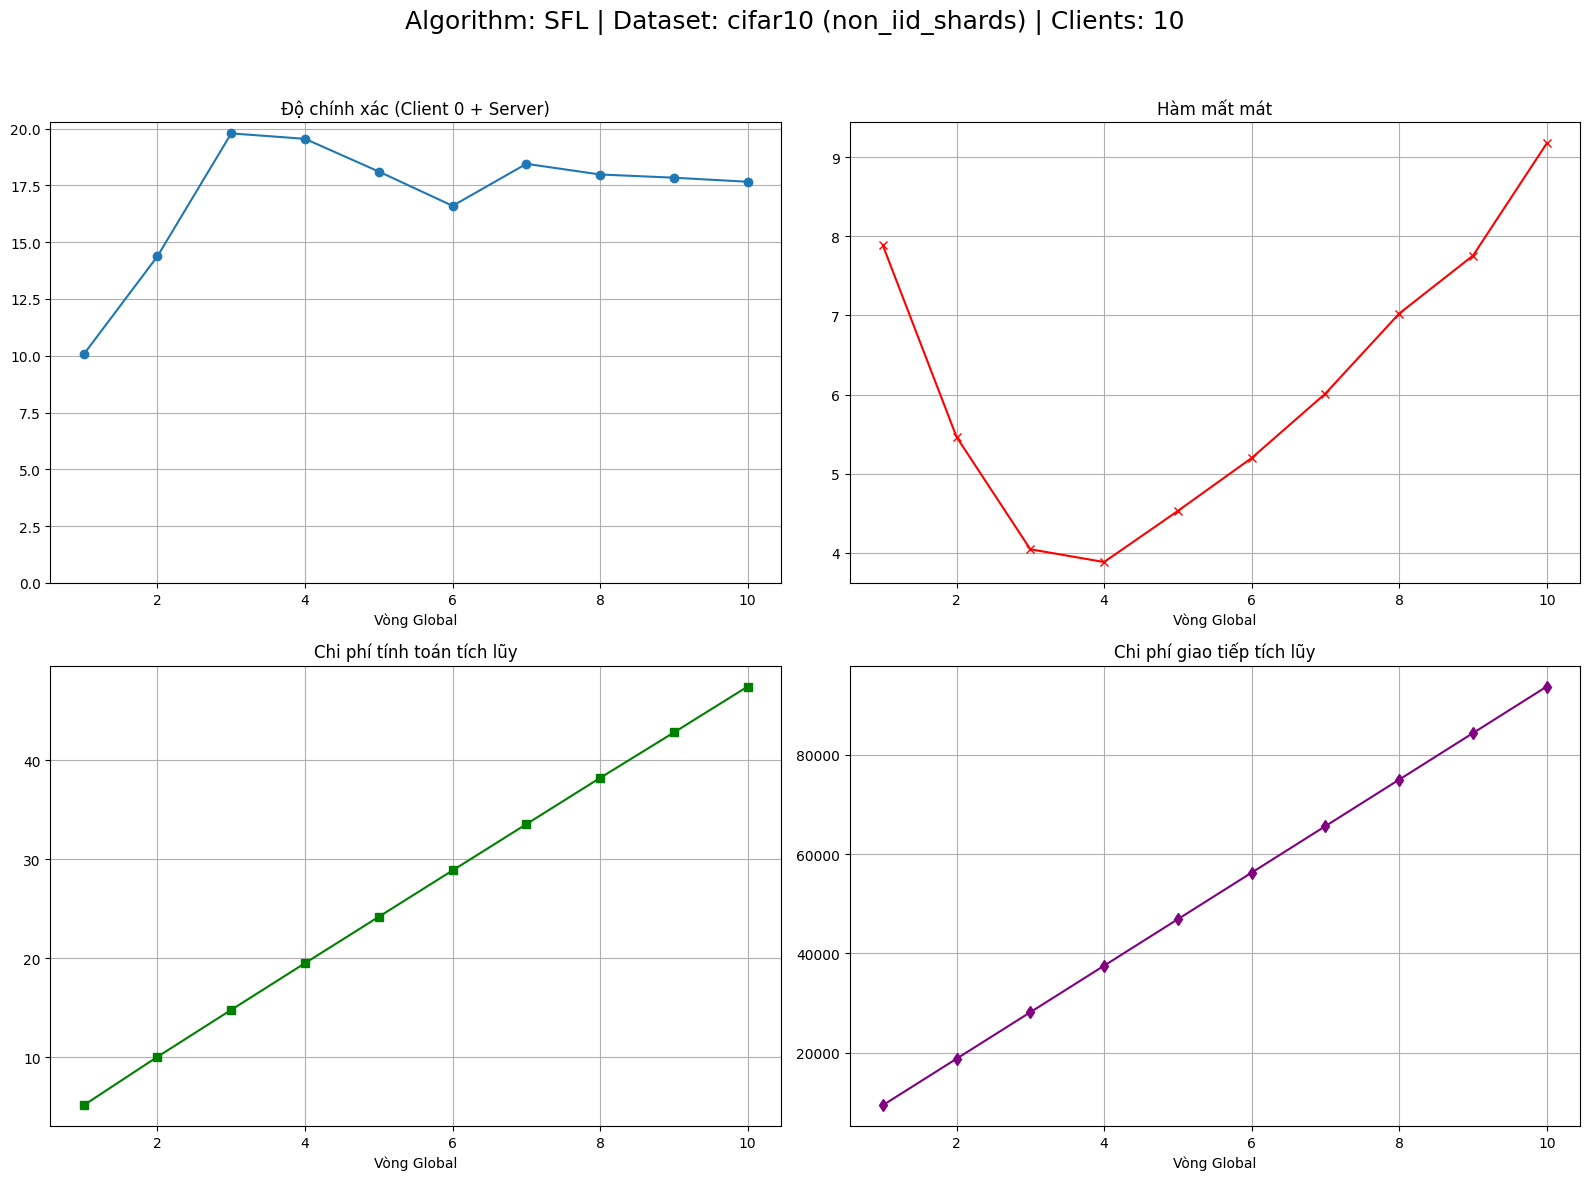

In [6]:
# Cell 6: Trực quan hóa kết quả 📊
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
title = (f"Algorithm: {config.ALGORITHM.upper()} | Dataset: {data_params['dataset_name']} "
         f"({data_params['distribution_mode']}) | Clients: {num_clients}")
fig.suptitle(title, fontsize=18)
rounds = history['rounds']
axes[0, 0].plot(rounds, history['accuracy'], marker='o'); axes[0, 0].set_title("Độ chính xác (Client 0 + Server)"); axes[0, 0].grid(True); axes[0, 0].set_ylim(bottom=0)
axes[0, 1].plot(rounds, history['loss'], marker='x', color='r'); axes[0, 1].set_title("Hàm mất mát"); axes[0, 1].grid(True)
axes[1, 0].plot(rounds, np.cumsum(history['comp_cost']), marker='s', color='g'); axes[1, 0].set_title("Chi phí tính toán tích lũy"); axes[1, 0].grid(True)
axes[1, 1].plot(rounds, np.cumsum(history['comm_cost']), marker='d', color='purple'); axes[1, 1].set_title("Chi phí giao tiếp tích lũy"); axes[1, 1].grid(True)
for ax in axes.flat: ax.set_xlabel("Vòng Global")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()